# `Лабораторная работа №1`

## Импорт библиотек

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow.keras import models, layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

## Подготовка данных

У столбцов не было названий, поэтому при чтении датасета они были добавлены вручную.

In [118]:
column_names = ['buying', 'maint', 'doors', 'persons', 'lug', 'safety', 'car_class']

data = pd.read_csv("car_evaluation.csv", header=None, names=column_names)
data.head()

,buying,maint,doors,persons,lug,safety,car_class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [119]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   buying     1728 non-null   str  
 1   maint      1728 non-null   str  
 2   doors      1728 non-null   str  
 3   persons    1728 non-null   str  
 4   lug        1728 non-null   str  
 5   safety     1728 non-null   str  
 6   car_class  1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


In [120]:
data.isna().sum()

buying       0
maint        0
doors        0
persons      0
lug          0
safety       0
car_class    0
dtype: int64

In [121]:
for i in column_names:
    print(data[i].unique())

<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
<StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
<StringArray>
['2', '4', 'more']
Length: 3, dtype: str
<StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
<StringArray>
['low', 'med', 'high']
Length: 3, dtype: str
<StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


Дубликатов обнаружено не было

---

Выделение целевого признака и разбитие на обучающие и тестовые наборы

In [122]:
features = ['buying', 'maint', 'doors', 'persons', 'lug', 'safety']
target = 'car_class'

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
categorical_features = ['buying', 'maint', 'doors', 'persons', 'lug', 'safety']
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

target_encoder = OneHotEncoder(sparse_output=False)
y_train = target_encoder.fit_transform(np.array(y_train).reshape(-1, 1))
y_test = target_encoder.transform(np.array(y_test).reshape(-1, 1))

## Построение нейронной сети

In [124]:
model = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),    
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="softmax") 
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

c:\Users\kitte\OneDrive\Рабочий стол\ML PY\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Обучение сети

In [125]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy}')

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3676 - loss: 1.3359 - val_accuracy: 0.6763 - val_loss: 1.1175
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7098 - loss: 0.9185 - val_accuracy: 0.6792 - val_loss: 0.7998
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7192 - loss: 0.6772 - val_accuracy: 0.7254 - val_loss: 0.6345
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7945 - loss: 0.5488 - val_accuracy: 0.7832 - val_loss: 0.5305
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8292 - loss: 0.4643 - val_accuracy: 0.8410 - val_loss: 0.4510
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8603 - loss: 0.4029 - val_accuracy: 0.8642 - val_loss: 0.3918
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.3546 - val_accuracy: 0.8671 - val_loss: 0.3417
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8864 - loss: 0.3152 - val_accuracy: 0.8757 - val_loss:

## Оценка и анализ результатов

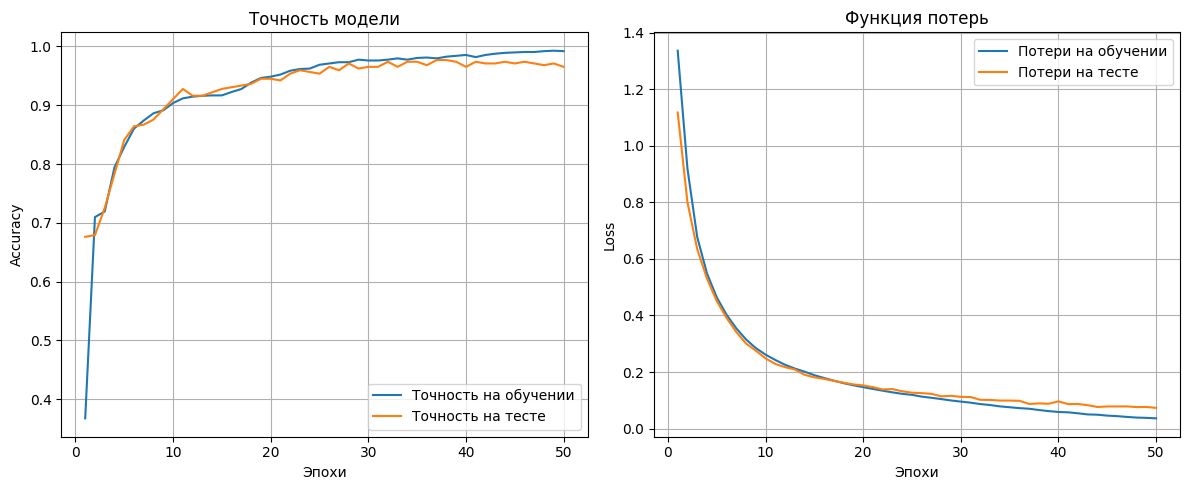

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность на обучении')
plt.plot(epochs_range, val_acc, label='Точность на тесте')
plt.title('Точность модели')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Потери на обучении')
plt.plot(epochs_range, val_loss, label='Потери на тесте')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Выводы:
`Высокая точность:` Модель достигла отличных показателей (97-98% на тесте), что говорит о правильной предобработке данных и выборе архитектуры.

`Стабильная сходимость:` Кривые потерь (Loss) плавно снижаются без резких скачков, подтверждая корректность оптимизатора Adam и размера батча.

`Легкое переобучение:` После 20-25 эпохи точность на обучении продолжает расти к 100%, в то время как на тесте она выходит на плато. Оранжевая линия потерь (val_loss) начинает медленно отдаляться от синей.

`Оптимальная точка:` Обучение можно было остановить на 20-30 эпохе — это обеспечило бы максимальную точность при лучшей обобщающей способности.

---

## Дополнительное исследование

In [133]:
neuron_counts = [32, 64, 128, 256]
research_acc = []
research_loss = []

for n in neuron_counts:    
    model_extra = models.Sequential([
        layers.Dense(n, activation="relu", input_shape=(X_train.shape[1],)),    
        layers.Dense(8, activation="relu"),
        layers.Dense(4, activation="softmax")
    ])
    
    model_extra.compile(optimizer="adam", 
                        loss="categorical_crossentropy", 
                        metrics=["accuracy"])
        
    model_extra.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)
    
    loss, accuracy = model_extra.evaluate(X_test, y_test, verbose=0)
    research_acc.append(accuracy)
    research_loss.append(loss)
    print(f"Завершено: {n} нейронов -> Accuracy: {accuracy:.4f}  Loss: {loss:.4f}")

c:\Users\kitte\OneDrive\Рабочий стол\ML PY\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Завершено: 32 нейронов -> Accuracy: 0.9827  Loss: 0.0784
Завершено: 64 нейронов -> Accuracy: 0.9855  Loss: 0.0431
Завершено: 128 нейронов -> Accuracy: 0.9884  Loss: 0.0328
Завершено: 256 нейронов -> Accuracy: 0.9913  Loss: 0.0224


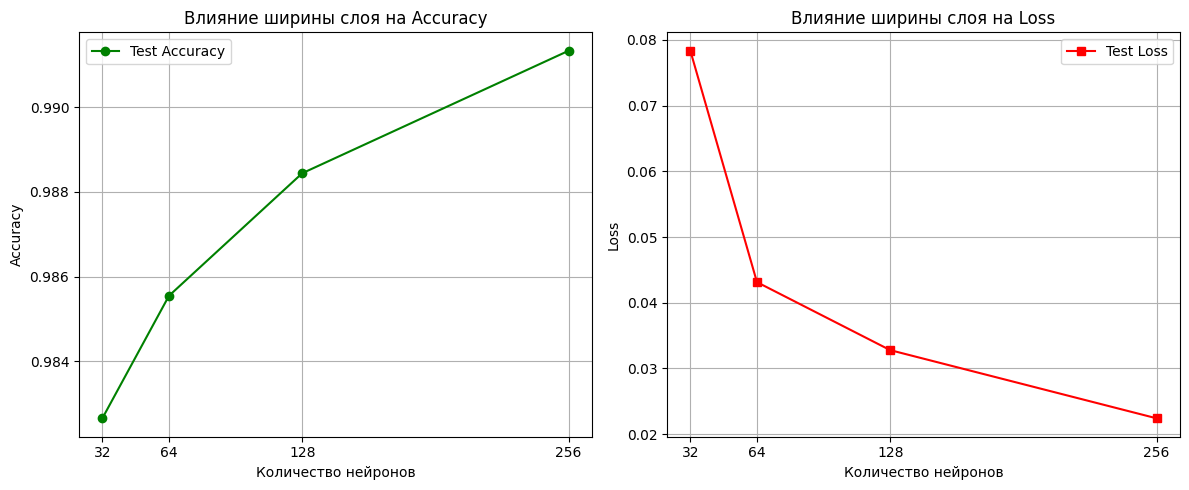

In [ ]:
plt.figure(figsize=(12, 5))

# --- График 1: Точность в зависимости от нейронов ---
plt.subplot(1, 2, 1)
plt.plot(neuron_counts, research_acc, marker='o', color='green', label='Test Accuracy')
plt.title('Влияние количества нейронов на Accuracy')
plt.xlabel('Количество нейронов')
plt.ylabel('Accuracy')
plt.xticks(neuron_counts) # Чтобы на оси были только наши значения
plt.legend()
plt.grid(True)

# --- График 2: Потери в зависимости от нейронов ---
plt.subplot(1, 2, 2)
plt.plot(neuron_counts, research_loss, marker='s', color='red', label='Test Loss')
plt.title('Влияние количества нейронов на Loss')
plt.xlabel('Количество нейронов')
plt.ylabel('Loss')
plt.xticks(neuron_counts)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Выводы по доп. исследованию

`Стабильный рост точности:` С увеличением количества нейронов от 32 до 256 наблюдается практически линейный рост точности на тестовой выборке. Модель с 256 нейронами показала лучший результат, преодолев отметку 0.991 (99.1%) по метрике Accuracy.

`Снижение функции потерь:` График Loss зеркально подтверждает успех: потери падают с ~0.078 (при 32 нейронах) до рекордных ~0.022 (при 256 нейронах). Это говорит о том, что более широкие слои позволяют модели лучше минимизировать ошибку.

`Эффект «замедления» прогресса:` Заметьте, что самый резкий скачок качества произошел при переходе от 32 к 64 нейронам. После этого кривая точности становится чуть более пологой. Это классический пример того, что начальное увеличение сложности дает максимальный профиль, а дальнейшее — лишь тонкую настройку.

`Отсутствие переобучения (пока что):` Тот факт, что тестовая точность продолжает расти, а потери — падать, означает, что даже при 256 нейронах модель еще не начала «зубрить» шум и сохраняет отличную способность к обобщению.

---
Для данного датасета архитектура с 256 нейронами является наиболее эффективной из протестированных. Однако, учитывая, что разница в точности между 128 и 256 нейронами невелика (менее 0.5%), вариант со 128 нейронами можно считать «золотой серединой» между скоростью работы и качеством предсказания.